In [1]:
from typing import List, Tuple
from cmath import exp
import numpy as np
import scipy.linalg as la
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def fill_subspace_matrices(
    mat_elems: List[complex], overlaps: List[complex]
) -> Tuple[np.ndarray, np.ndarray]:
    """Fill subspace matrices from the computed matrix elements and overlaps."""

    assert len(mat_elems) == len(overlaps)
    d = len(mat_elems)
    h = np.zeros((d, d), dtype=complex)
    s = np.zeros((d, d), dtype=complex)
    for i in range(d): # Loop over rows.
        for j in range(d):
            if i == j:
                h[i, i] = mat_elems[0]
                s[i, i] = overlaps[0]
            elif i > j:
                h[i, j] = mat_elems[i - j]
                s[i, j] = overlaps[i - j]
            else: # i < j
                h[i, j] = mat_elems[j - i].conjugate()
                s[i, j] = overlaps[j - i].conjugate()
    return h, s

def subspace_matrices(b, delta_e, d, t):
    """Calculate H and S in the 2D subspace given b."""

    norm_b2 = la.norm(b) ** 2
    overlaps = []
    matrix_elements = []
    for k in range(d):
        bn2_exp = 0. # sum_{n=1}^Q |b_n|^2 exp(-i n t dE k)
        n_bn2_exp = 0. # sum_{n=1}^Q n |b_n|^2 exp(-i n t dE k)
        for n in range(1, b.size + 1):
            bn2_exp += abs(b[n - 1]) ** 2 * exp(n * complex(0., -1.) * t * delta_e * k)
            n_bn2_exp += n * abs(b[n - 1]) ** 2 * exp(n * complex(0., -1.) * t * delta_e * k)
        overlaps.append(bn2_exp / norm_b2)
        matrix_elements.append(delta_e * n_bn2_exp / norm_b2)
    h, s = fill_subspace_matrices(matrix_elements, overlaps)
    return (h, s)

In [3]:
def threshold_eigenvalues(h: np.ndarray, s: np.ndarray, eps: float) -> Tuple[np.ndarray, np.ndarray]:
    """Remove all eigenvalues below a positive threshold eps.
    See Epperly et al. sec. 1.2."""

    # Build a matrix whose columns correspond to the positive eigenvectors of s.
    evals, evecs = la.eigh(s)
    positive_evals = []
    positive_evecs = []
    for i, ev in enumerate(evals):
        assert abs(ev.imag) < 1e-7
        if ev.real > eps:
            positive_evals.append(ev.real)
            positive_evecs.append(evecs[:, i])
    pos_evec_mat = np.vstack(positive_evecs).T
    # Project h and s into this subspace.
    new_s =  pos_evec_mat.conj().T @ s @ pos_evec_mat
    new_h = pos_evec_mat.conj().T @ h @ pos_evec_mat
    return new_h, new_s


def kyrlov_energy(h, s, eps):
    h_new, s_new = threshold_eigenvalues(h, s, eps)
    eigvals, _ = la.eigh(h_new, s_new)
    return np.min(eigvals)

In [4]:
def energy_avg_std(q, delta_e, d, t, eps, shots):
    ground_state_energies = []
    for _ in range(shots):
        b = np.random.normal(loc=0., scale=1., size=q)
        h, s = subspace_matrices(b, delta_e, d, t)
        energy = kyrlov_energy(h, s, eps)
        ground_state_energies.append(energy)
    avg = np.average(ground_state_energies)
    std = np.std(ground_state_energies)
    return (avg, std)

In [5]:
q = 100
delta_e = 1.0
shots = 10_000
eps = 1e-8

ds = [5, 10, 20]
ts = np.linspace(0.001, 10.0, num=5)
dfs = []
for d in ds:
    records = []
    for t in ts:
        avg, std = energy_avg_std(q, delta_e, d, t, eps, shots)
        records.append((t, avg, std))

    df = pd.DataFrame.from_records(records, columns=["t", "avg", "std"])
    df.set_index("t", inplace=True)
    df["d"] = d
    dfs.append(df)

big_df = pd.concat(dfs)

In [6]:
print(big_df.head())

                avg       std  d
t                               
0.00100   12.096770  2.201651  5
2.50075   40.065418  5.233568  5
5.00050   40.039323  5.002989  5
7.50025   40.054274  5.056690  5
10.00000  39.997162  5.062408  5


<Axes: xlabel='t', ylabel='avg'>

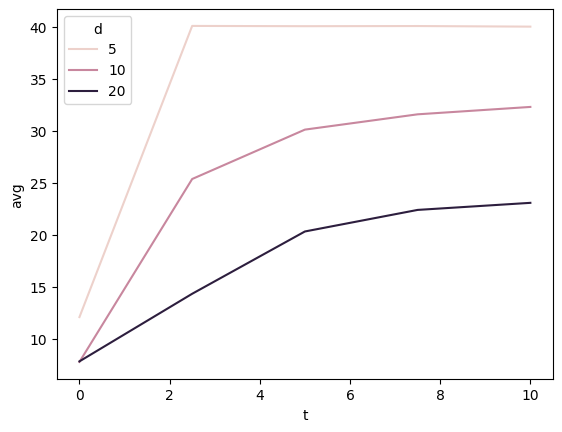

In [7]:
sns.lineplot(data=big_df, x="t", y="avg", hue="d")

<Axes: xlabel='t', ylabel='std'>

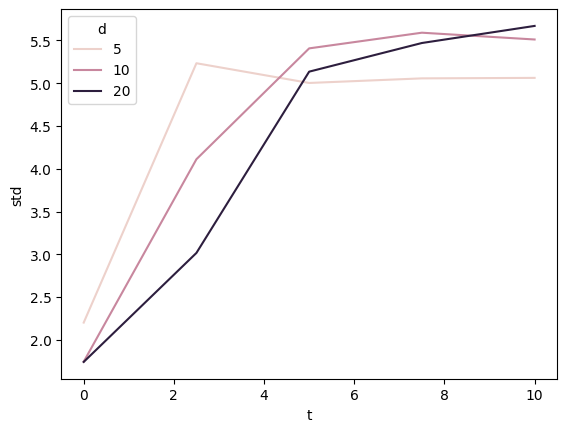

In [8]:
sns.lineplot(data=big_df, x="t", y="std", hue="d")